<a href="https://colab.research.google.com/github/debadeepTalukdar/ml_ml/blob/main/drone_failure_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


  DRONE FAILURE PREDICTOR ACCURACY: 99.70%



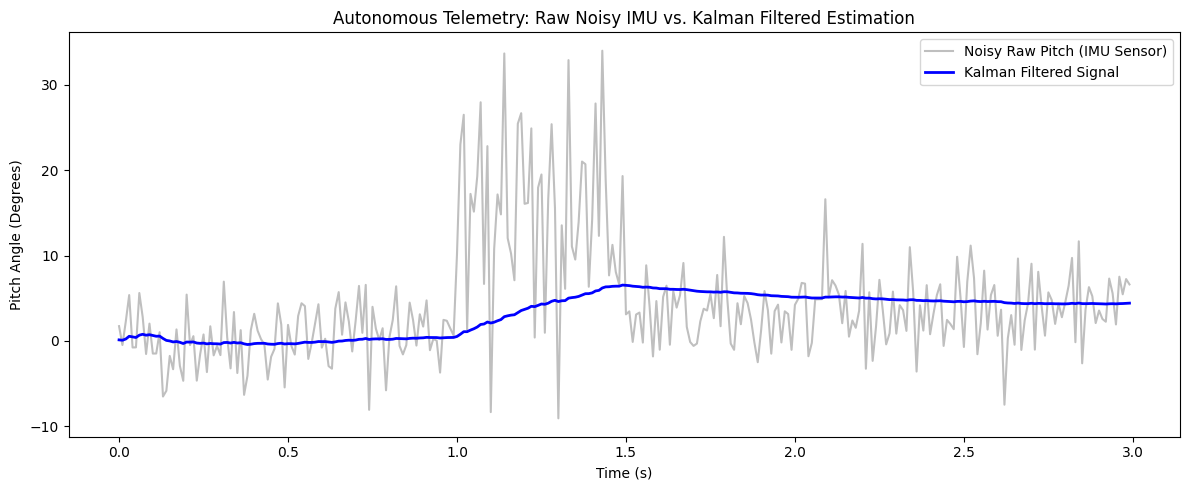

In [2]:
import numpy as np
import pandas as pd
from scipy.signal import medfilt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# 1. GENERATE SYNTHETIC FLIGHT TELEMETRY DATA (NO HARDWARE NEEDED)
# ---------------------------------------------------------
np.random.seed(42)
num_samples = 10000
time = np.linspace(0, 100, num_samples)

# True smooth Drone signals
true_pitch = np.sin(0.1 * time) * 15  # Pitch angle in degrees
true_roll = np.cos(0.1 * time) * 10   # Roll angle in degrees
true_altitude = 100 + 0.5 * time + np.sin(0.05 * time) * 5

# Add sensor noise (Simulating cheap IMU readings)
noisy_pitch = true_pitch + np.random.normal(0, 3.5, num_samples)
noisy_roll = true_roll + np.random.normal(0, 3.0, num_samples)
noisy_altitude = true_altitude + np.random.normal(0, 2.0, num_samples)

# Create failure conditions (Stall / Sensor Failure / Unstable Oscillation)
failure_labels = np.zeros(num_samples)
for i in range(100, num_samples - 100, 400):
    if np.random.rand() > 0.6:
        # Inject instability/failure over a 50-step window
        failure_labels[i:i+50] = 1
        noisy_pitch[i:i+50] += np.random.normal(15, 8, 50)  # Extreme vibration
        noisy_roll[i:i+50] += np.random.normal(-20, 10, 50)
        noisy_altitude[i:i+50] -= np.linspace(0, 15, 50)    # Rapid altitude drop

df = pd.DataFrame({
    'Time': time,
    'Pitch_Raw': noisy_pitch,
    'Roll_Raw': noisy_roll,
    'Altitude_Raw': noisy_altitude,
    'Failure_State': failure_labels
})

# ---------------------------------------------------------
# 2. IMPLEMENT DIGITAL SIGNAL PROCESSING (KALMAN / LOW-PASS FILTERING)
# ---------------------------------------------------------
class Simple1DKalmanFilter:
    def __init__(self, process_variance, measurement_variance):
        self.q = process_variance
        self.r = measurement_variance
        self.x = 0.0  # initial estimate
        self.p = 1.0  # initial estimate error

    def update(self, measurement):
        self.p = self.p + self.q
        k = self.p / (self.p + self.r)
        self.x = self.x + k * (measurement - self.x)
        self.p = (1 - k) * self.p
        return self.x

kf_pitch = Simple1DKalmanFilter(process_variance=1e-3, measurement_variance=3.5**2)
kf_roll = Simple1DKalmanFilter(process_variance=1e-3, measurement_variance=3.0**2)

df['Pitch_Kalman'] = [kf_pitch.update(m) for m in df['Pitch_Raw']]
df['Roll_Kalman'] = [kf_roll.update(m) for m in df['Roll_Raw']]

# Feature Engineering: Rate of change (Velocity/Derivatives) & Variance
df['Pitch_Velocity'] = df['Pitch_Kalman'].diff().fillna(0)
df['Roll_Velocity'] = df['Roll_Kalman'].diff().fillna(0)
df['Pitch_Variance_5step'] = df['Pitch_Raw'].rolling(window=5).var().fillna(0)

# ---------------------------------------------------------
# 3. TRAIN XGBOOST FLIGHT FAILURE PREDICTOR
# ---------------------------------------------------------
features = ['Pitch_Kalman', 'Roll_Kalman', 'Altitude_Raw', 'Pitch_Velocity', 'Roll_Velocity', 'Pitch_Variance_5step']
X = df[features]
y = df['Failure_State']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = xgb.XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred) * 100

print("\n==========================================")
print(f"  DRONE FAILURE PREDICTOR ACCURACY: {acc:.2f}%")
print("==========================================\n")

# ---------------------------------------------------------
# 4. PLOT & SAVE SIGNAL FILTERING VISUALIZATION
# ---------------------------------------------------------
plt.figure(figsize=(12, 5))
plt.plot(df['Time'][:300], df['Pitch_Raw'][:300], alpha=0.5, label='Noisy Raw Pitch (IMU Sensor)', color='gray')
plt.plot(df['Time'][:300], df['Pitch_Kalman'][:300], label='Kalman Filtered Signal', color='blue', linewidth=2)
plt.title('Autonomous Telemetry: Raw Noisy IMU vs. Kalman Filtered Estimation')
plt.xlabel('Time (s)')
plt.ylabel('Pitch Angle (Degrees)')
plt.legend()
plt.tight_layout()
plt.savefig('kalman_telemetry_filter.png')
plt.show()